**Defensive Matchup Extension**

This part of the model looks to understand the effect of different types of defence and their effect on offensive decision making, to do this, each individual player's defensive rating was taken from NBAStuffer's 2022-23 season player stats to help split defence into **Below Average**, **Average** and **Above Average**

**Import required libraries and read dataset**

In [1]:
# import required libraries for analysis
! pip install nashpy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import nashpy as nash

# from google.colab import drive
# drive.mount('/content/drive')
# df = pd.read_csv('/content/drive/MyDrive/2022-23 play-by-play.csv')

# read 2022-23 play-by-play dataset
df = pd.read_csv('2022-23 play-by-play.csv')

# read 2022-23 player stats dataset
df_defence = pd.read_csv('NBA_Stats_Defence.csv')

**Classify defender by defensive rating (DRtg)**

This section of code uses the classify_defender function to split players from the dataset based on drtg rating, drtg refers to the amount of points a player lets in so the less points they let in the better.

In [2]:
def classify_defender(drtg):
  if pd.isna(drtg):
    return 'Average Defender'
  # if a player lets in less than 107 points, classify as 'Above Average'
  elif drtg < 107:
    return 'Above Average Defender'
  # if a player lets in 110 points or less classify as 'Average Defender'
  elif drtg <= 110:
    return 'Average Defender'
  # anything else is classed as a below average defender
  else:
    return 'Below Average Defender'

# apply function to stats_defence dataset
df_defence['tier'] = df_defence['DRtg'].apply(classify_defender)


print("Number of Defenders per tier")
print()
print(df_defence['tier'].value_counts())

Number of Defenders per tier

tier
Below Average Defender    246
Above Average Defender    213
Average Defender          150
Name: count, dtype: int64


**Merge defender and shot data**

The 2022-23 pbp dataset provides the statistics for shooting but does not provide any data in regards to a team or individual player's defensive quality therefore, DRtg stats taken from the stats_defence dataset is merged with the shooting data by taking the average DRtg for each team and merging this with the shot data.

The average DRtg for each team is then used to split defences into Above Average
Average or Below Average tiers

In [3]:
# code for error handling, allows code to be 're-runnable'
for i in ['away_team', 'home_team', 'defending_team']:
  if i in df.columns:
    df.drop(columns=[i], inplace=True)
df['team'] = df['team'].str.lower().str.capitalize()

# gather the average DRtg per team to determine defensive quality score
team_drtg = df_defence.groupby('TEAM')['DRtg'].mean().reset_index()
team_drtg.columns = ['opponent_team', 'avg_DRtg']

# use a dictionary to lookup player name and their associated team
player_team = df_defence.set_index('NAME')['TEAM'].to_dict()

# identify home and away teams for each game by taking
# the first player from the home team (h1) column and away team (a1) column
game_teams = df.groupby('game_id').first()[['a1', 'h1']].reset_index()
game_teams['away_team'] = game_teams['a1'].map(player_team)
game_teams['home_team'] = game_teams['h1'].map(player_team)

# merge into pbp dataframe
df = df.merge(game_teams[['game_id', 'away_team', 'home_team']],
              on='game_id', how='left')

# capatilise home and away teams to reduce logic errors since the pbp dataset
# capatilises team names whereas the stats_defence dataset does not
df['away_team'] = df['away_team'].str.capitalize()
df['home_team'] = df['home_team'].str.capitalize()
df['team'] = df['team'].str.capitalize()

# if the shooting team is the away team then the defending team is the home
# team and vice versa
df['defending_team'] = None
df.loc[df['team'] == df['away_team'], 'defending_team'] = df['home_team']
df.loc[df['team'] == df['home_team'], 'defending_team'] = df['away_team']

# gather 3PT shot data from pbp dataset as seen in previous model steps
three_point_shot = df[
    (df['event_type'] == 'shot') &
    (df['shot_distance'] >= 22)
].copy()
three_point_shot['made'] = (three_point_shot['result'] == 'made').astype(int)

# merge team average DRtg onto the 3PT attempts from the pbp dataset
three_point_shot = three_point_shot.merge(
    team_drtg, left_on='defending_team', right_on='opponent_team', how='left'
)

# classify each defending team into a tier using previous func
three_point_shot['defender_tier'] = three_point_shot['avg_DRtg'].apply(
    classify_defender
)

# print distribution
print()
print("Shot Events per Defender type")
print(three_point_shot['defender_tier'].value_counts())
print()


Shot Events per Defender type
defender_tier
Average Defender          50384
Above Average Defender    24654
Below Average Defender    16195
Name: count, dtype: int64



**Get 3PT% and Contest Level by Defender**

In [4]:
# create function for defensive pressure
def defensive_matchup(row):
  # get coordinates of shot location
  x = row.get('converted_x')
  y = row.get('converted_y')

  # define defensive pressure based on shot location
  if pd.isna(x) or pd.isna(y):
    return 'Unknown'

  if x > 40 and abs(y) > 20:
    return 'Sag Off'

  elif x > 30 and abs(y) < 15:
    return 'Hard-Close Out'

  else:
    return 'Moderate Contest'

# apply contest classification to each 3PT attempt
three_point_shot['contest'] = three_point_shot.apply(defensive_matchup, axis=1)

# compute emprical 3PT% for each defender tier and contest type
contest_percentage = three_point_shot.groupby([
    'defender_tier', 'contest'
])['made'].mean()

# print distribution
print('3PT% per contest level')
print(contest_percentage.round(3))

3PT% per contest level
defender_tier           contest         
Above Average Defender  Hard-Close Out      0.364
                        Moderate Contest    0.354
                        Sag Off             0.362
                        Unknown             0.400
Average Defender        Hard-Close Out      0.375
                        Moderate Contest    0.355
                        Sag Off             0.367
                        Unknown             0.667
Below Average Defender  Hard-Close Out      0.414
                        Moderate Contest    0.367
                        Sag Off             0.369
Name: made, dtype: float64


**Get action frequencies for each defender type**

In [5]:
shot_mask = df['event_type'] == 'shot'

df['action'] = None
# create a mask to identify where event is shot
df.loc[shot_mask & (df['shot_distance'] >= 22), 'action'] = 'Shoot'
# create a mask to identify where event is drive
df.loc[shot_mask & (df['shot_distance'] < 10), 'action'] = 'Drive'

# filter to rows with an action then merge DRtg as well
actions = df[df['action'].notna()].copy()
actions = actions.merge(
    team_drtg, left_on='defending_team', right_on='opponent_team', how='left'
)

# classify each actions defending team into a defensive tier using
# classify_defender func
actions['defender_tier'] = actions['avg_DRtg'].apply(classify_defender)

# get % frequency per defender tier
action_frequency = actions.groupby([
    'defender_tier', 'action'
]).size().unstack(fill_value=0)
action_frequency_percentage = action_frequency.div(
    action_frequency.sum(axis=1), axis=0
) * 100

# print distribution
print("Action Frequencies per Defensive Tier (%)")
print()
print(action_frequency_percentage.round(2))

Action Frequencies per Defensive Tier (%)

action                  Drive  Shoot
defender_tier                       
Above Average Defender  51.50  48.50
Average Defender        53.00  47.00
Below Average Defender  54.57  45.43


**Recompute payoff matrix for each defender tier**

In [6]:
# function to recompute the payoff matrix per defender tier
def defensive_matchup_payoff_matrix(tier, tier_contest_stats):
  # defensive contest actions
  contests = ['Hard-Close Out', 'Moderate Contest', 'Sag Off']
  # default 3PT%
  defaults = [0.362, 0.342, 0.352]

  # get empirical 3PT% else fall back to defaults when data is unavailable
  if tier in tier_contest_stats.index.get_level_values(0):
    variables = (
        tier_contest_stats.loc[tier]
        .reindex(contests).fillna(dict(zip(contests, defaults)))
        .to_numpy()
    )
  else:
    variables = np.array(defaults)

  # create fatigue adjustment for drive actions
  drive_pressure = {'Above Average Defender': -0.02,
                   'Average Defender': 0.00,
                   'Below Average Defender': 0.02}.get(tier, 0)

  # baseline model statistics
  baseline_drive = 0.701
  free_throw_drive = 1.562
  free_throw_shoot = 2.343
  pass_points = 1.142
  foul_rate = 0.133
  turnover = 0.141

  # shoot payoff
  shoot = variables * 3 + foul_rate * free_throw_shoot

  # drive payoff
  drive_mods = np.array([0.05, 0.00, -0.05])
  drive = (
     (baseline_drive + drive_mods + drive_pressure)
      * 2 * (1 - turnover)
  + (foul_rate * free_throw_drive)
  )

  # create payoff matrix
  return np.vstack([
      shoot,
      drive,
  ])

defence_tiers = ['Above Average Defender', 'Average Defender',
                  'Below Average Defender']
tier_matrices = {} # store payoff matrix
tier_equilibria = {} # store equilibria

# print recomputed matrix
for tier in defence_tiers:
    tier_matrices[tier] = defensive_matchup_payoff_matrix(
        tier, contest_percentage)
    print(f"\n{tier}-Clock Payoff Matrix:")
    print(tier_matrices[tier].round(3))


Above Average Defender-Clock Payoff Matrix:
[[1.404 1.372 1.397]
 [1.464 1.378 1.292]]

Average Defender-Clock Payoff Matrix:
[[1.437 1.377 1.414]
 [1.498 1.412 1.326]]

Below Average Defender-Clock Payoff Matrix:
[[1.553 1.413 1.42 ]
 [1.532 1.446 1.361]]


**Solve for Nash Equilibrium**

In [7]:
for tier in defence_tiers:
  # create a game using payoff matrix
  game = nash.Game(tier_matrices[tier], -tier_matrices[tier])

  # solve for Nash equilibrium by using support enumeration
  equilibrium = list(game.support_enumeration())

  # compute equilibrium and print results
  if equilibrium:
    offence, defence = equilibrium[0]
    tier_equilibria[tier] = {
        'offence': offence,
        'defence': defence
    }
    print(f"{tier} Equilibria")
    print(f"Shoot {round(offence[0]*100, 2)}%")
    print(f"Drive {round(offence[1]*100, 2)}%")

Above Average Defender Equilibria
Shoot 77.75%
Drive 22.25%
Average Defender Equilibria
Shoot 69.86%
Drive 30.14%
Below Average Defender Equilibria
Shoot 92.67%
Drive 7.33%


**Visualisations to compare models for results writing**

In [8]:
"""
this section of the notebook creates a comparison table between the baseline
and empirical model to be able to visualise the shooting and drive % for each
fatigue state
"""

# create a list to be able to store the results
defensive_matchup_comparison = []

for tier in defence_tiers:
  # fetch the equilibrium probabilites
  baseline = tier_equilibria.get(tier, {}).get('offence', [np.nan, np.nan])
  # fetch empirical frequencies
  empirical = action_frequency_percentage.loc[tier] if tier in action_frequency_percentage.index else pd.Series()

  # add the statistics to the results list defined earlier
  defensive_matchup_comparison.append([
      tier,
      baseline[0] * 100,
      empirical.get('Shoot', 0),
      baseline[1] * 100,
      empirical.get('Drive', 0),
      baseline[0] * 100 - empirical.get('Shoot', 0)
  ])

# create the comparisn table
comparison_df = pd.DataFrame(
    defensive_matchup_comparison,
    columns=[
        'Defender_Tier',
        'Baseline_Shoot%',
        'Empirical_Shoot%',
        'Baseline_Drive%',
        'Empirical_Drive%',
        'Difference'
    ]
).round(2)

# print comparison table
print("Model Comparison")
print()
print(comparison_df)

Model Comparison

            Defender_Tier  Baseline_Shoot%  Empirical_Shoot%  Baseline_Drive%  \
0  Above Average Defender            77.75             48.50            22.25   
1        Average Defender            69.86             47.00            30.14   
2  Below Average Defender            92.67             45.43             7.33   

   Empirical_Drive%  Difference  
0             51.50       29.25  
1             53.00       22.86  
2             54.57       47.25  


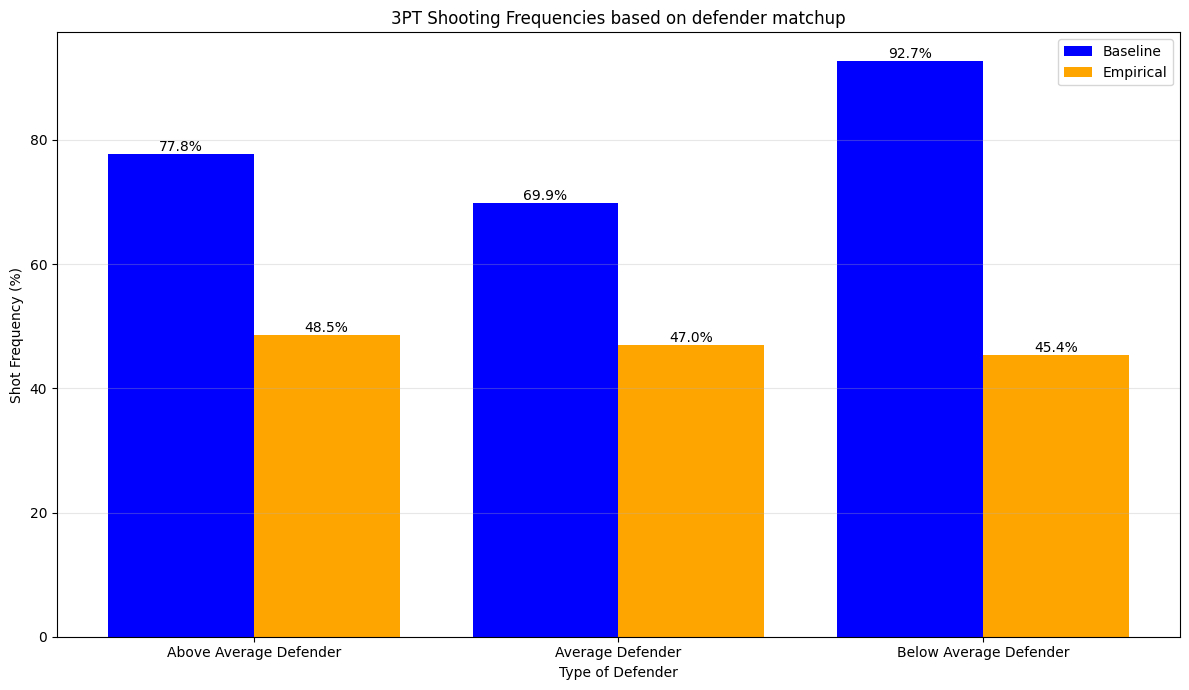

In [9]:
"""
create a visualisation graph to show the frequencies of both shoot and drive
for each clock segment
"""

# extract baseline and empirical frequencies
baseline_shooting = [tier_equilibria[s]['offence'][0] * 100 for s in defence_tiers]
empirical_shooting = [action_frequency_percentage.loc[s].get('Shoot', 0)
                     if s in action_frequency_percentage.index else 0
                     for s in defence_tiers]

# create graph
fig, br = plt.subplots(figsize=(12,7))

# label x axis as clock segments
x = np.arange(len(defence_tiers))

width = 0.40

# plot baseline bar
br.bar(x - 0.2, baseline_shooting, width, label='Baseline', color='blue')
# plot empirical bar
br.bar(x + 0.2, empirical_shooting, width, label='Empirical', color='orange')

# plot graph details
br.set_xticks(x)
br.set_ylabel('Shot Frequency (%)')
br.set_xlabel('Type of Defender')
br.set_xticklabels(defence_tiers)
br.set_title('3PT Shooting Frequencies based on defender matchup')
br.legend()
br.grid(axis='y', alpha=0.3)

# add % labels on the bars
for bars in br.containers:
  br.bar_label(bars, fmt='%.1f%%')

# show graph output
plt.tight_layout()
plt.show()